<a href="https://colab.research.google.com/github/gowriv05/Data_visualization_python/blob/main/Data_Visualization_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taxi Data Analysis

This project focuses on cleaning, analyzing, and visualizing taxi trip data using Pandas, Matplotlib, and Seaborn.

The analysis includes:
- Data loading
- Data understanding
- Missing value analysis
- Missing value treatment
- Outlier detection and removal
- Basic statistical analysis
- Data visualization
- Insights and findings

## 1. Loading the Dataset

The Seaborn taxis dataset is loaded using the load_dataset() function.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Loading the 'taxis' dataset
df = sns.load_dataset("taxis")
df.head()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


In [ ]:
df.tail()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn
6432,2019-03-13 19:31:22,2019-03-13 19:48:02,1,3.85,15.0,3.36,0.0,20.16,green,credit card,Boerum Hill,Windsor Terrace,Brooklyn,Brooklyn


## 2. Understanding the Dataset

Before cleaning the data, we check the shape, column names, data types, and basic statistical information.

In [ ]:
# Total no. of rows and columns
df.shape

(6433, 14)

In [ ]:
# Columns names
df.columns

Index(['pickup', 'dropoff', 'passengers', 'distance', 'fare', 'tip', 'tolls',
       'total', 'color', 'payment', 'pickup_zone', 'dropoff_zone',
       'pickup_borough', 'dropoff_borough'],
      dtype='object')

In [ ]:
# Checking data types
df.dtypes

,0
pickup,datetime64[ns]
dropoff,datetime64[ns]
passengers,int64
distance,float64
fare,float64
tip,float64
tolls,float64
total,float64
color,object
payment,object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   object        
 13  dropoff_borough  6388 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(

In [ ]:
df.describe()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total
count,6433,6433,6433.000000,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000
mean,2019-03-16 08:31:28.514223616,2019-03-16 08:45:49.491217408,1.539251,3.024617,13.091073,1.97922,0.325273,18.517794
min,2019-02-28 23:29:03,2019-02-28 23:32:35,0.000000,0.000000,1.000000,0.00000,0.000000,1.300000
25%,2019-03-08 15:50:34,2019-03-08 16:12:51,1.000000,0.980000,6.500000,0.00000,0.000000,10.800000
50%,2019-03-15 21:46:58,2019-03-15 22:06:44,1.000000,1.640000,9.500000,1.70000,0.000000,14.160000
75%,2019-03-23 17:41:38,2019-03-23 17:51:56,2.000000,3.210000,15.000000,2.80000,0.000000,20.300000
max,2019-03-31 23:43:45,2019-04-01 00:13:58,6.000000,36.700000,150.000000,33.20000,24.020000,174.820000
std,NaN,NaN,1.203768,3.827867,11.551804,2.44856,1.415267,13.815570


## 3. Separating Numerical and Categorical Columns

Numerical columns contain numerical values, while categorical columns contain labels or categories.

In [ ]:
# numerical columns and categorical columns
numerical_columns=df.select_dtypes(include="number").columns
categorical_columns=df.select_dtypes(include="object").columns

In [ ]:
numerical_columns

Index(['passengers', 'distance', 'fare', 'tip', 'tolls', 'total'], dtype='object')

In [ ]:
categorical_columns

Index(['color', 'payment', 'pickup_zone', 'dropoff_zone', 'pickup_borough',
       'dropoff_borough'],
      dtype='object')

## 4. Checking Missing Values

Missing values are checked in each column.

In [ ]:
df.isnull().sum()

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,44


In [ ]:
missing_percentage=(df.isnull().sum())/len(df)*100
missing_percentage[missing_percentage>0]

,0
payment,0.683973
pickup_zone,0.404166
dropoff_zone,0.699518
pickup_borough,0.404166
dropoff_borough,0.699518


## Missing Value Handling

The missing value percentage for all columns was less than 5%.
Based on the given data cleaning rule, rows containing missing values were removed using the dropna() method.

In [ ]:
# Deleting the missing values rows
df=df.dropna()

In [ ]:
# checking missing values after handling
df.isnull().sum()

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,0


In [ ]:
# checking duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(6341, 14)

## Sorting

The dataset is sorted based on the pickup timestamp so that the trips are arranged in chronological order for time-based visualization.

In [ ]:
df=df.sort_values('pickup')

1. Line Chart – Fare Over Time

A line chart is created to visualize the variation in taxi fare over time. The pickup timestamp is used on the x-axis, and fare is used on the y-axis.

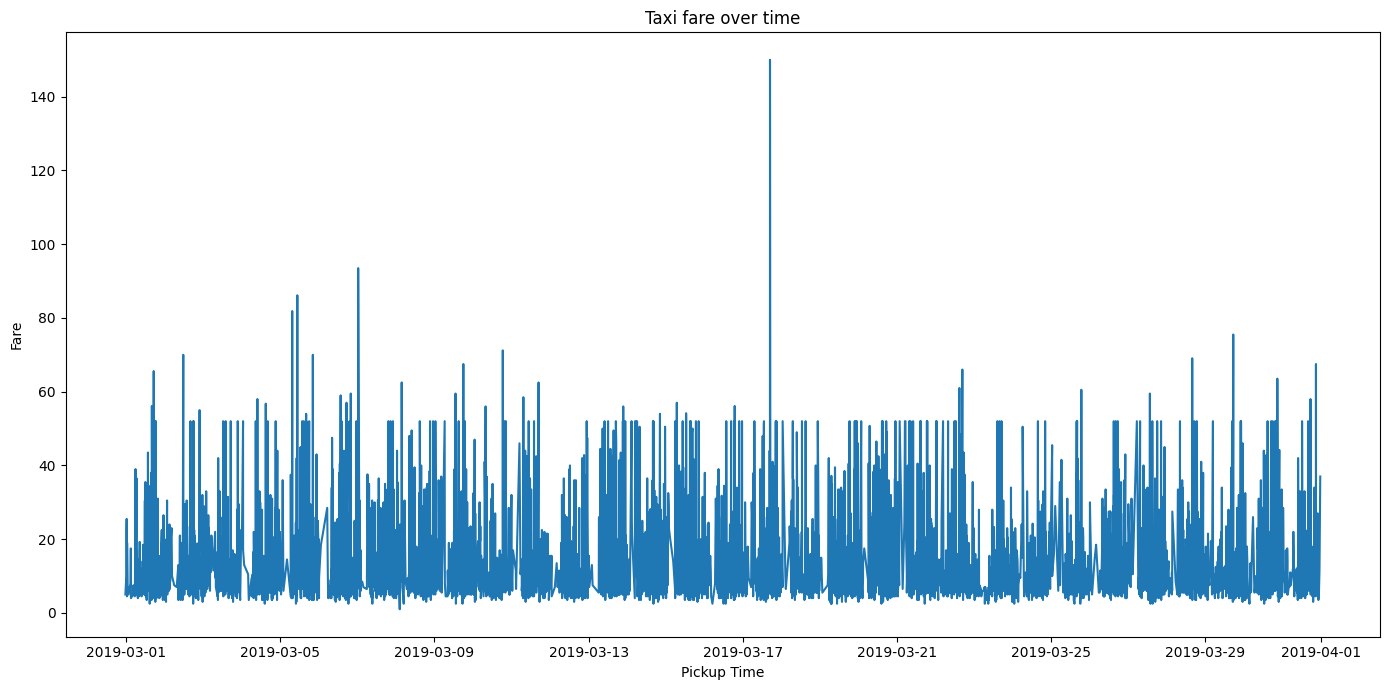

In [ ]:
plt.figure(figsize=(14,7))
plt.plot(df['pickup'],df['fare'])
plt.xlabel('Pickup Time')
plt.ylabel('Fare')
plt.title('Taxi fare over time')
plt.tight_layout()
plt.show()


Insight:
Taxi fares are mostly concentrated between 5 and 30 over the observed period. However, there are several sudden spikes in fare, with the highest fare reaching around 150. The fare values fluctuate considerably throughout the period.

## 2. Bar Chart – Total Fare by Pickup Borough

A bar chart is created to compare the total fare generated from each pickup borough. The data is grouped by `pickup_borough`, and the fare values are summed for each borough.


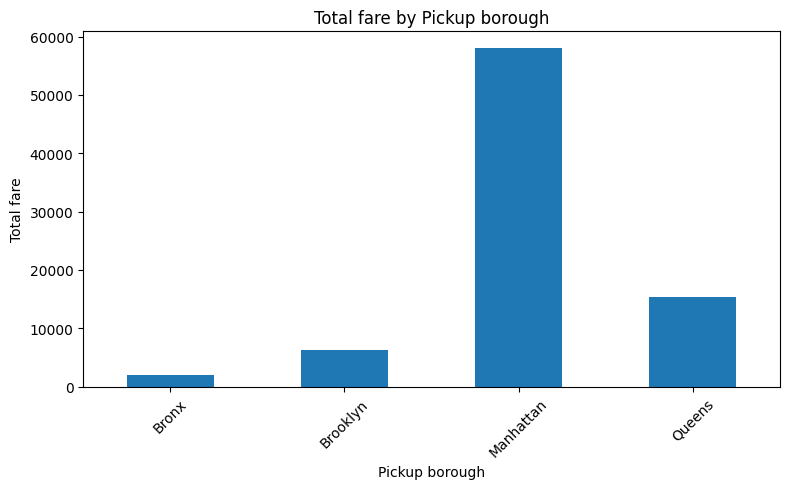

In [ ]:
borough_fare=df.groupby('pickup_borough')['fare'].sum()
borough_fare.plot(kind='bar',figsize=(8,5))
plt.xlabel('Pickup borough')
plt.ylabel('Total fare')
plt.title('Total fare by Pickup borough')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Insight:
Manhattan generates the highest total fare, at around 58,000. Queens is next with around 15,000, followed by Brooklyn with around 6,000, while Bronx has the lowest total fare at around 2,000.

## 3. Pie Chart – Payment Method Distribution

A pie chart is created to show the distribution of taxi trips based on payment method. Each slice represents the number of trips made using a particular payment method.


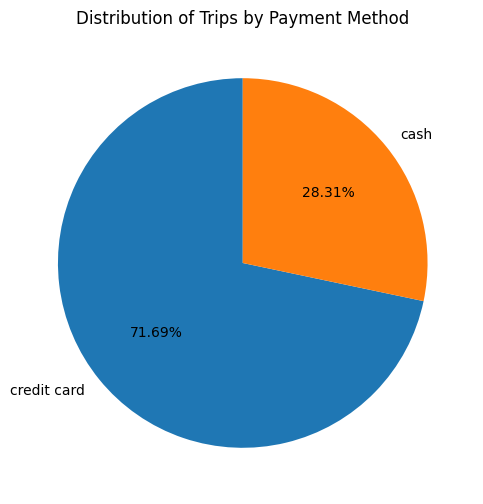

In [ ]:
payment_counts = df['payment'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(payment_counts,labels=payment_counts.index,autopct='%1.2f%%',startangle=90)
plt.title('Distribution of Trips by Payment Method')
plt.show()

Insight:
There are two payment methods: credit card and cash. Credit card is used for 71.69% of the trips, while cash accounts for 28.31%.
Therefore, credit card is the most commonly used payment method.

## 4. Histogram – Distribution of Trip Distance

A histogram is created to visualize the distribution of taxi trip distances. The number of bins is customized to provide better granularity and make the distribution easier to interpret.


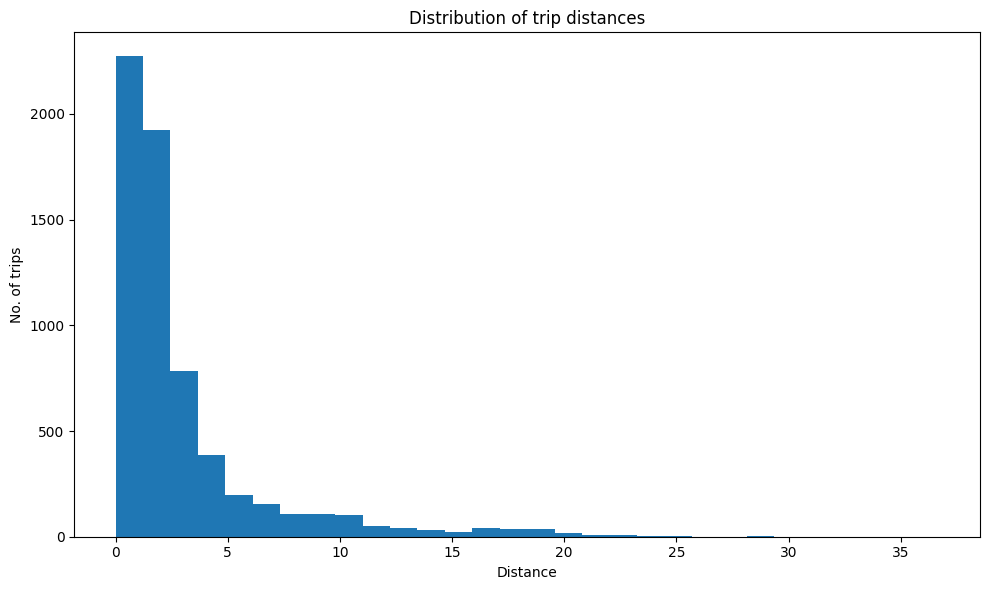

In [ ]:
plt.figure(figsize=(10,6))
plt.hist(df['distance'],bins=30)
plt.xlabel('Distance')
plt.ylabel('No. of trips')
plt.title('Distribution of trip distances')
plt.tight_layout()
plt.show()

Insight:
Most taxi trips are short-distance trips, mainly concentrated below around 5 units of distance. As distance increases, the number of trips decreases significantly. Only a small number of trips are very long, extending up to around 37 units.

## 5. Box Plot – Tip Distribution by Pickup Borough

A box plot is created to visualize the distribution of tip amounts across different pickup boroughs. `pickup_borough` is used as the categorical variable and `tip` is used as the numerical variable.


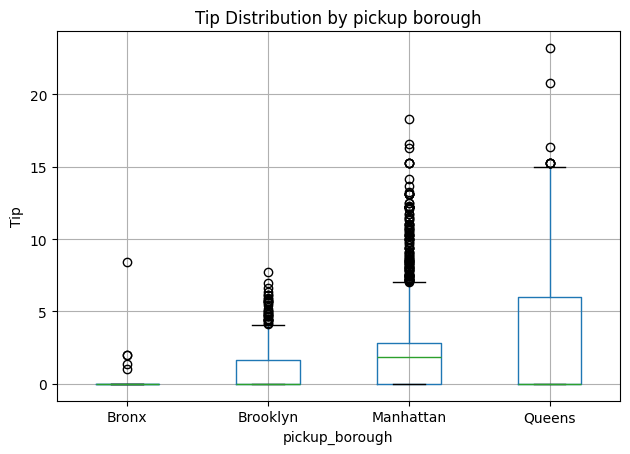

In [ ]:
df.boxplot(column='tip',by='pickup_borough')
plt.xlabel('pickup_borough')
plt.ylabel('Tip')
plt.title('Tip Distribution by pickup borough')
plt.suptitle('')
plt.tight_layout()
plt.show()

Insight:
Manhattan and Queens show higher tip values and wider distributions compared with Bronx and Brooklyn. Manhattan has many high-value tip outliers, while Queens also has some very high tip values, reaching above 20. Bronx has the lowest overall tip distribution.

## 6. Count Plot – Number of Trips by Pickup Borough

A Seaborn count plot is created to visualize the number of taxi trips in each pickup borough. The x-axis represents the pickup borough, while the y-axis represents the number of trips.


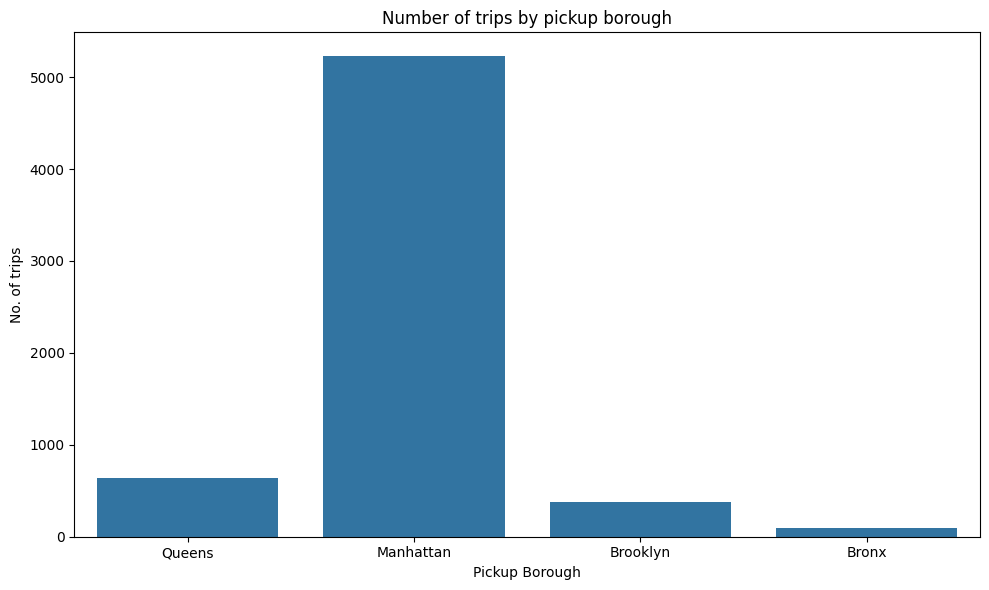

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(data=df,x='pickup_borough')
plt.xlabel('Pickup Borough')
plt.ylabel('No. of trips')
plt.title('Number of trips by pickup borough')
plt.tight_layout()
plt.show()

Insight:
Manhattan has by far the highest number of trips, with more than 5,000 trips. Queens has around 600 trips, Brooklyn around 350, and Bronx has the lowest number of trips.

## 7. Scatter Plot – Distance vs Fare

A scatter plot is created to examine the relationship between trip distance and fare. Distance is plotted on the x-axis and fare on the y-axis. The points are colored according to the pickup borough to compare trips from different boroughs.


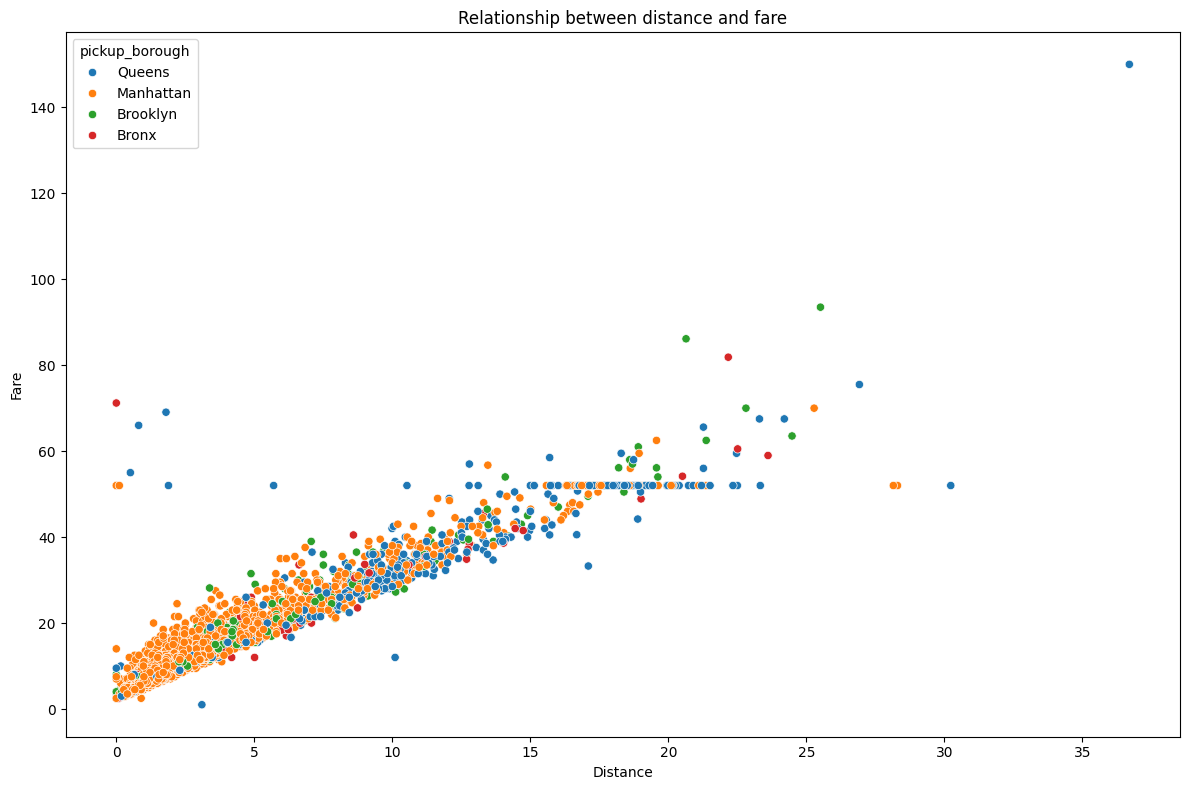

In [ ]:
plt.figure(figsize=(12,8))
sns.scatterplot(data=df,x='distance',y='fare',hue='pickup_borough')
plt.xlabel('Distance')
plt.ylabel('Fare')
plt.title('Relationship between distance and fare')
plt.tight_layout()
plt.show()

Insight: The points show a clear positive relationship between distance and fare. As the trip distance increases, the fare generally increases. Most trips are concentrated at shorter distances and lower fares, while longer trips generally have higher fares.

## 8. Heatmap – Correlation Between Numerical Variables

A correlation heatmap is created to examine the relationships between numerical variables such as distance, fare, tip, tolls, and total. The correlation matrix is visualized using a heatmap to make the strength and direction of relationships easier to understand.


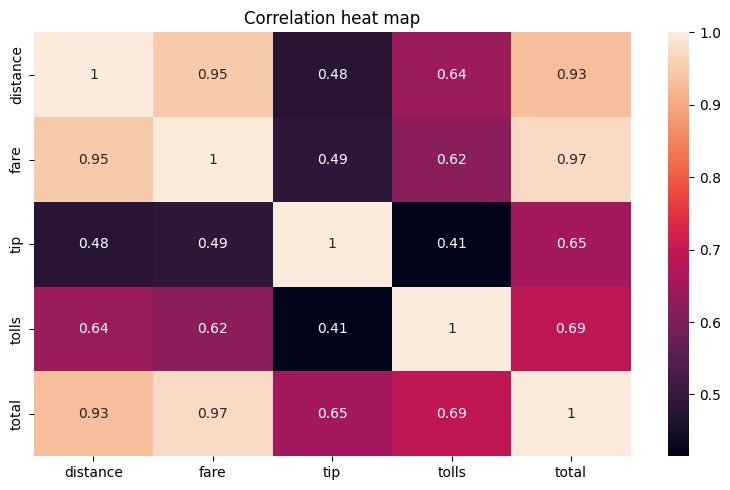

In [ ]:
correlation=df[['distance','fare','tip','tolls','total']].corr()
plt.figure(figsize=(8,5))
sns.heatmap(correlation,annot=True)
plt.title('Correlation heat map')
plt.tight_layout()
plt.show()


Insight: Fare and total have the strongest positive correlation (0.97), followed by distance and fare (0.95). This indicates that longer trips are strongly associated with higher fares and total amounts.

## 9. Pair Plot – Pairwise Relationships

A pair plot is created to visualize pairwise relationships among distance, fare, tip, and total. The points are colored according to the pickup zone to compare the patterns across different pickup zones.


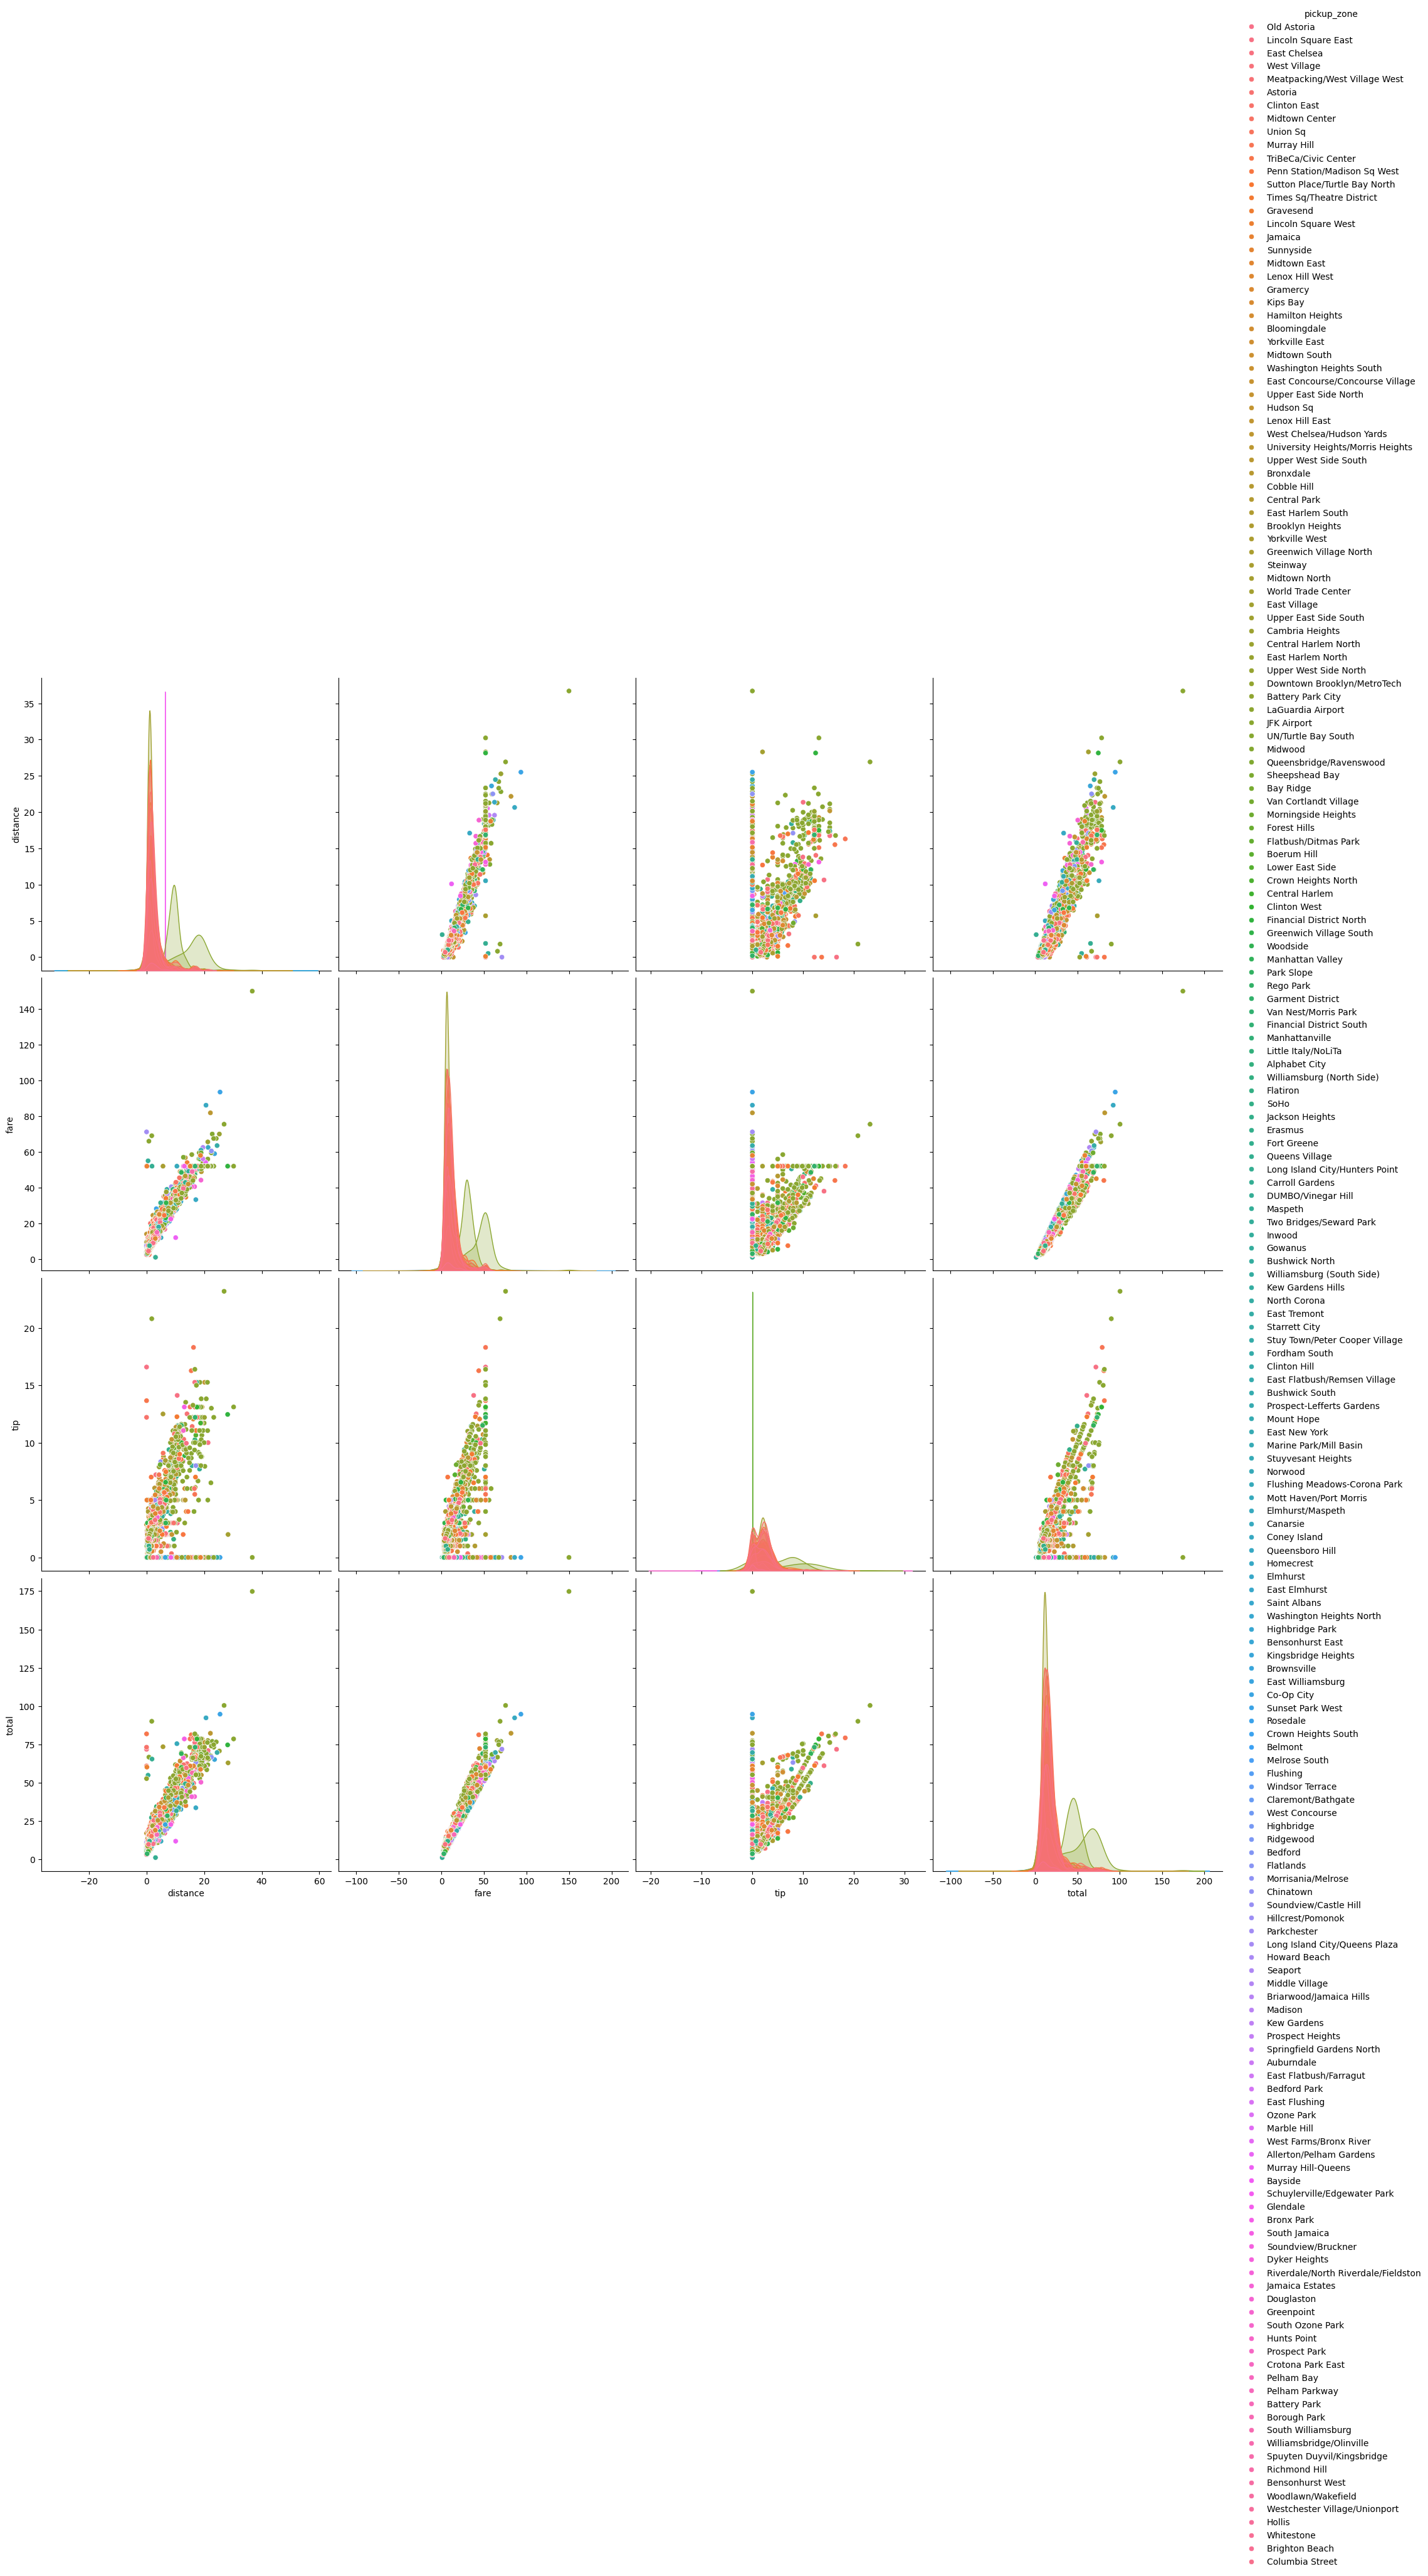

In [ ]:
pair_data=df[['distance','fare','tip','total','pickup_zone']]
sns.pairplot(pair_data,vars=['distance','fare','tip','total'],hue='pickup_zone',height=5)
plt.show()

Insight:
The pair plot shows a strong positive relationship between distance, fare, and total. As distance increases, fare and total generally increase. Tip also shows a positive relationship with fare and total, but the relationship is weaker compared with distance and fare.

## 10. Violin Plot – Fare Distribution by Payment Method

A violin plot is created to visualize the distribution of taxi fares across different payment methods. The payment method is used as the categorical variable and fare is used as the numerical variable.


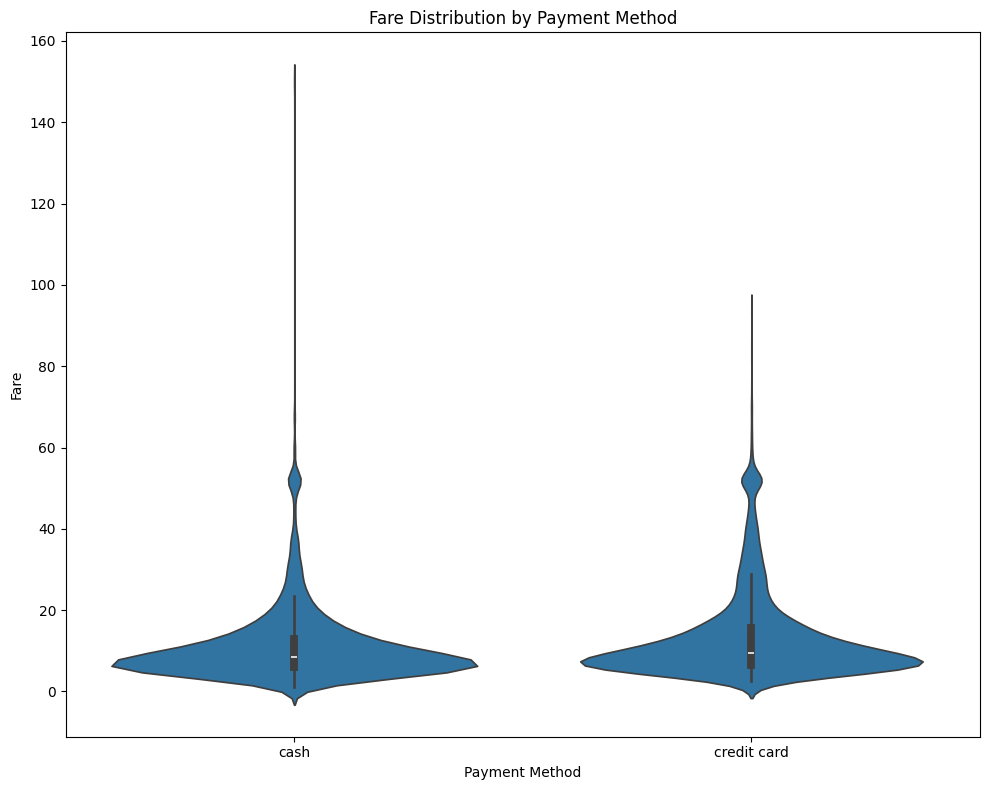

In [ ]:
plt.figure(figsize=(10,8))
sns.violinplot(data=df,x='payment',y='fare')
plt.xlabel('Payment Method')
plt.ylabel('Fare')
plt.title('Fare Distribution by Payment Method')
plt.tight_layout()
plt.show()

Insight:
Both payment methods have a similar concentration of fares at the lower fare range. However, cash shows a wider upper distribution and more extreme high-fare values, with the upper tail reaching around 155, while credit card fares extend to around 100 in this dataset.